# Introduction to Data Science 2025

# Bonus exercises

## Exercise 1: EDA of unemployed highly educated people in Finland

In this assignment, you will explore time series data on unemployment of highly educated people in Finland combined with two datasets of your own choosing. The idea of the assignment is to look into how the unemployed highly educated population varies over time and across different areas by using the data wrangling, exploratory data analysis, and visualization tools discussed during the course.

First, please download the Statistics Finland's CSV dataset (available in the course MOOC Materials) that contains data on employment and unemployment numbers grouped by level of education, province, and year.

Read in the data to a data frame, and have a look at the rows and columns it contains. For ease of use, you can set the year column as the index. Perform any other preprocessing you see fit. If you are working in Python, you can do this using the pandas library. 

**Hint**: you can also create new useful columns using the existing ones. 

In [12]:
## Use this cell for your code
import pandas as pd
from matplotlib import pyplot as plt

path = "./unemployment_data.csv"
df_unemployment = pd.read_csv(path, encoding='latin1')
df_unemployment.set_index("Year", inplace=True)

print(df_unemployment.head())
print(df_unemployment.info())
print(df_unemployment.columns)



              Area Main type of activity  \
Year                                       
1987  MK01 Uusimaa                 Total   
1987  MK01 Uusimaa                 Total   
1987  MK01 Uusimaa              Employed   
1987  MK01 Uusimaa              Employed   
1987  MK01 Uusimaa            Unemployed   

                                     Level of education  Population 31 Dec  
Year                                                                        
1987                                              Total            1199530  
1987  7-8 Master's or equivalent level or doctoral o...              65757  
1987                                              Total             653347  
1987  7-8 Master's or equivalent level or doctoral o...              55702  
1987                                              Total              13998  
<class 'pandas.core.frame.DataFrame'>
Index: 4218 entries, 1987 to 2023
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtyp

Next, find two time series datasets of your choice to combine with the unemployment data. These can be time series data on factors that you are interested in that might be connected to unemployment, and should cover at least some of the same years as the unemployment data. Please find the datasets from some source other than Statistics Finland (Tilastokeskus).

Read in your datasets, perform any necessary cleaning (such as handling missing values or removing unnecessary columns, et cetera). Preprocess the data so that the features are presented on a yearly level. Then, combine the preprocessed datasets to the unemployment data using the year column to link the datasets.

In [13]:
# data source https://fred.stlouisfed.org/series/NYGDPPCAPKDFIN
df_gdp = pd.read_csv("NYGDPPCAPKDFIN.csv", encoding='latin1')
df_gdp['Year'] = pd.to_datetime(df_gdp['observation_date']).dt.year
df_gdp = df_gdp[['Year', 'NYGDPPCAPKDFIN']]
# df_gdp.set_index('Year', inplace=True)

print(df_gdp.head())

# data source https://data.worldbank.org/indicator/FP.CPI.TOTL.ZG
df_infl = pd.read_csv("inflation_data.csv")
df_infl_fin = df_infl[df_infl['Country Code'] == 'FIN']
df_infl_fin = df_infl_fin.drop(columns=['Country Name','Country Code','Indicator Name','Indicator Code'])
year_cols = [col for col in df_infl_fin.columns if col.isdigit()]
df_infl_long = df_infl_fin.melt(
    id_vars=[],  # no id_vars since we only kept numeric columns
    value_vars=year_cols,
    var_name='Year',
    value_name='Inflation'
)
df_infl_long['Year'] = df_infl_long['Year'].astype(int)
print(df_infl_long.head())

# merge
df_master = df_unemployment[df_unemployment['Level of education'].str.contains("Master", case=False)]

df_pivot = df_master.pivot_table(
    index=['Year','Area','Level of education'],
    columns='Main type of activity',
    values='Population 31 Dec',
    aggfunc='sum'
).reset_index()

df_pivot['unemployment_rate'] = (df_pivot['Total'] - df_pivot['Employed']) / df_pivot['Total']
df_yearly = df_pivot.groupby('Year')['unemployment_rate'].mean().reset_index()

# print(df_yearly.head())

df_merged = pd.merge(df_yearly, df_gdp, on='Year', how='left')
df_merged = pd.merge(df_merged, df_infl_long, on='Year', how='left')
print(df_merged.head())

   Year  NYGDPPCAPKDFIN
0  1960    11153.778617
1  1961    11917.585493
2  1962    12189.788934
3  1963    12501.539417
4  1964    13083.467678
   Year  Inflation
0  1960   3.418127
1  1961   1.691002
2  1962   4.383983
3  1963   4.996382
4  1964  10.275861
   Year  unemployment_rate  NYGDPPCAPKDFIN  Inflation
0  1987           0.137806    28412.449795   4.113029
1  1988           0.143576    29811.950940   5.085929
2  1989           0.140244    31214.675016   6.592910
3  1990           0.143923    31291.522259   6.149565
4  1991           0.156722    29290.977395   4.310213


Perform exploratory data analysis on your merged dataset. You can use methods of your choice to compute useful statistics on the data, and to visualize different features and the interactions between them. Focus on the question of whether high education level (Master's level) and other factors in your merged dataset are associated with unemployment.

              Year  unemployment_rate  NYGDPPCAPKDFIN  Inflation
count    37.000000          37.000000       37.000000  37.000000
mean   2005.000000           0.208289    38883.417375   2.255327
std      10.824355           0.038440     6585.454091   1.982359
min    1987.000000           0.137806    27807.861466  -0.207929
25%    1996.000000           0.185307    31291.522259   0.877440
50%    2005.000000           0.201739    42412.513351   1.478286
75%    2014.000000           0.248879    44391.453567   3.042101
max    2023.000000           0.266659    46359.873284   7.123508
                   unemployment_rate  NYGDPPCAPKDFIN  Inflation
unemployment_rate           1.000000        0.778513  -0.349976
NYGDPPCAPKDFIN              0.778513        1.000000  -0.192928
Inflation                  -0.349976       -0.192928   1.000000


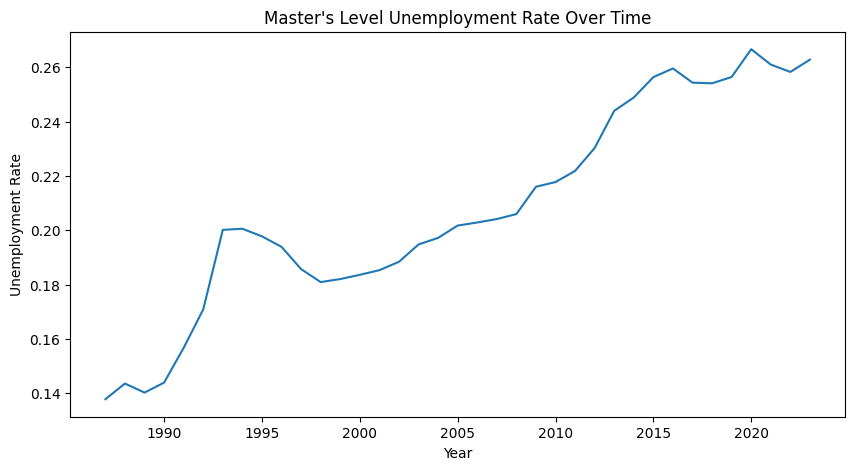

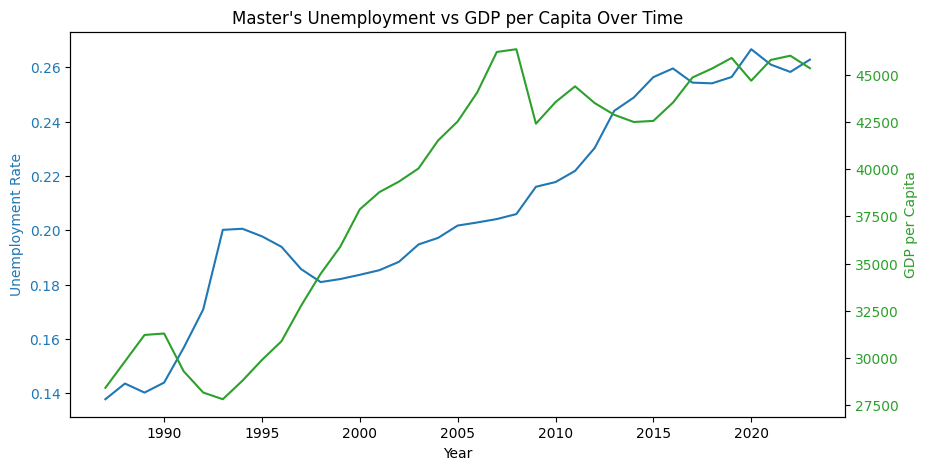

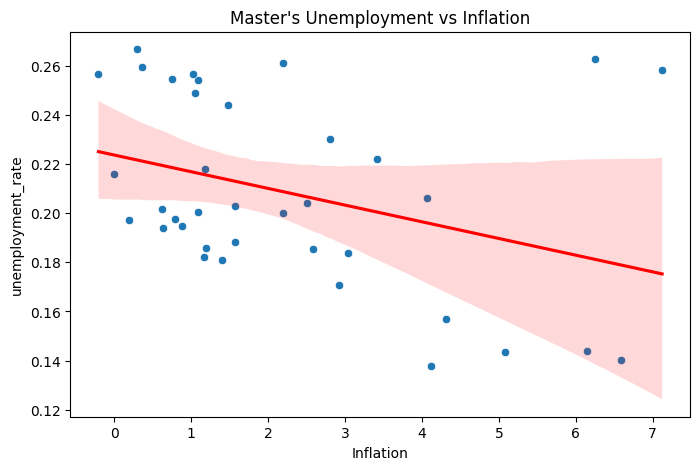

In [14]:
import seaborn as sns
print(df_merged.describe())

# Correlations
corr_cols = ['unemployment_rate', 'NYGDPPCAPKDFIN', 'Inflation']
print(df_merged[corr_cols].corr())
plt.figure(figsize=(10,5))
sns.lineplot(data=df_merged, x='Year', y='unemployment_rate')
plt.title("Master's Level Unemployment Rate Over Time")
plt.ylabel("Unemployment Rate")
plt.show()

# GDP vs Unemployment over time
fig, ax1 = plt.subplots(figsize=(10,5))
color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Unemployment Rate', color=color)
ax1.plot(df_merged['Year'], df_merged['unemployment_rate'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('GDP per Capita', color=color)
ax2.plot(df_merged['Year'], df_merged['NYGDPPCAPKDFIN'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title("Master's Unemployment vs GDP per Capita Over Time")
plt.show()

# Inflation vs Unemployment scatter
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_merged, x='Inflation', y='unemployment_rate')
sns.regplot(data=df_merged, x='Inflation', y='unemployment_rate', scatter=False, color='red')
plt.title("Master's Unemployment vs Inflation")
plt.show()


Create a geographical or other type of plot showcasing the trends in the unemployment of highly educated people across different provinces over time. Compare the provinces based on your plot.

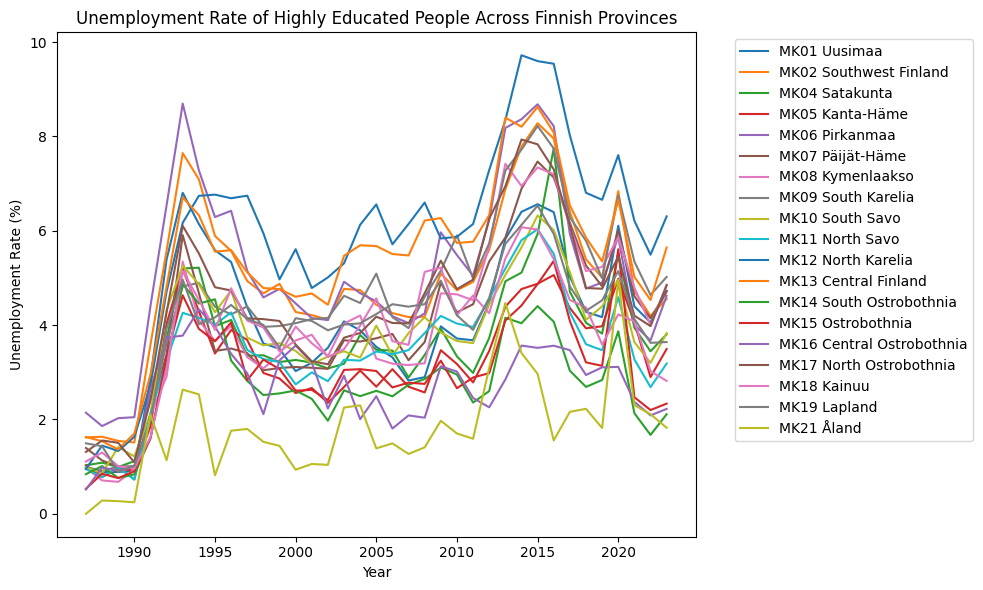

In [15]:
## Use this cell for your code
edu_df = df_unemployment[df_unemployment["Level of education"].str.contains("Master", na=False)]
edu_df = edu_df[edu_df["Main type of activity"].isin(["Employed", "Unemployed"])]

pivot = edu_df.pivot_table(
    index=["Year", "Area"],
    columns="Main type of activity",
    values="Population 31 Dec",
    aggfunc="sum"
).reset_index()

# Calculate unemployment rate
pivot["Unemployment Rate (%)"] = pivot["Unemployed"] / (pivot["Unemployed"] + pivot["Employed"]) * 100

# Plot trend lines
plt.figure(figsize=(10,6))
for area, group in pivot.groupby("Area"):
    plt.plot(group["Year"], group["Unemployment Rate (%)"], label=area)

plt.title("Unemployment Rate of Highly Educated People Across Finnish Provinces")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

import geopandas as gpd
import plotly.express as px

geo = gpd.read_file("./finland_provinces.geojson",encoding="UTF-8")

data_2020 = pivot[pivot["Year"] == 2020].copy()

data_2020["Area_clean"] = data_2020["Area"].str.split().str[1:].str.join(" ")

data_2020["Unemployment Rate (%)"] = pd.to_numeric(data_2020["Unemployment Rate (%)"], errors='coerce')

merged = geo.merge(data_2020, left_on="name", right_on="Area_clean")

fig = px.choropleth_mapbox(
    merged,
    geojson=merged.__geo_interface__,
    locations=merged.index,
    color="Unemployment Rate (%)",
    hover_name="Area_clean",
    mapbox_style="carto-positron",
    color_continuous_scale="RdYlBu_r",
    title="Unemployment Rate of Highly Educated People (2020)",
    center={"lat": 64.5, "lon": 26.0},
    zoom=3
)
fig.show()

Reflect briefly on your findings. For example, which features seemed interesting with respect to changes in unemployment among the highly educated population? How do different provinces compare? What should be done to ensure that the number of unemployed highly educated people can be compared fairly across years and provinces? 

**Hint**: should we look at the raw numbers or maybe consider them relative to something else?

## Exercise 2: AI Act

In this exercise, we ask you to think about the different AI services you come accross in your daily life and consider them in terms of the AI Act's risk pyramid.

1. Brainstorm & List: For 48 hours, keep a log of every application, software, or service you interact with that you suspect uses AI. Think about social media feeds, recommendation engines (Netflix, Spotify, Amazon), grammar checkers, spam filters, navigation apps, and virtual assistants. We'd expect that most of you will be able to identify at least 10 examples.

2. Select & Analyze: Choose three distinct AI systems from your list. For each one, research and describe its primary function and how AI is used to achieve it.

3. Classify the Risk: Using the AI Act's risk pyramid as a guide, classify each of your three chosen AI systems into one of the four categories:
	- Unacceptable Risk: Is the AI system doing something that is explicitly banned (e.g., social scoring, real-time remote biometric identification in public spaces by law enforcement)?
	- High-Risk: Could the system have a significant impact on your safety, fundamental rights, or access to essential services? (e.g., AI used in educational scoring, recruitment, or credit scoring). Justify why it falls into a specific high-risk category listed in Annex III of the Act.
	- Limited or Minimal Risk: Does the system interact with you in a way that should require transparency? (e.g., chatbots, deepfakes, generative AI).

4. Justify Your Reasoning: For each classification, write a short paragraph explaining your decision, referencing specific criteria from the AI Act.

### 1
- Netflix – content recommendation engine
- Spotify – personalized playlists and song suggestions
- Amazon – product recommendations and dynamic pricing
- Gmail – spam filters and smart reply suggestions
- Google Maps – route optimization and ETA predictions
- TikTok – feed ranking and content recommendation
- ChatGPT – virtual assistants
- LinkedIn – job recommendations and candidate ranking
- Online banking apps – fraud detection AI
- Grammarly – grammar and writing suggestions

### 2

1. Netflix Recommendation Engine

AI Usage: Uses machine learning models (collaborative filtering, neural networks) to predict what content a user is likely to enjoy. It analyzes watch history, ratings, and engagement patterns.

2. Grammarly

AI Usage: NLP (Natural Language Processing) and deep learning models analyze text input to detect errors and suggest improvements in real-time.

3. Online Banking Fraud Detection

AI Usage: Machine learning models analyze transaction patterns, device behavior, and historical fraud data to flag anomalies.

### 3
| AI System                          | Risk Category          | Justification                                                                                                                                                                                                                                                                                                                                                                |
| ---------------------------------- | ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Netflix Recommendation Engine**  | Limited / Minimal Risk | According to the AI Act, transparency is recommended for AI systems interacting with users in ways that influence behavior (Article 52). Netflix AI recommends content but does not significantly impact fundamental rights or safety. Users should be informed that recommendations are AI-driven, but the risk is minimal.                                                 |
| **Grammarly**                      | Limited / Minimal Risk | Grammarly uses AI to assist users but does not affect essential services or legal rights. Transparency is relevant: users should know the suggestions are AI-generated. It falls under “AI systems interacting with humans” that have limited risk.                                                                                                                          |
| **Online Banking Fraud Detection** | High-Risk              | Fraud detection can directly impact access to essential financial services, making it high-risk under Annex III of the AI Act (e.g., credit scoring and financial decision-making). Errors or false positives could deny users access to their funds or create financial harm. Therefore, strict compliance with risk management, accuracy, and human oversight is required. |
